# Introducción a la Estadística Bayesiana

In [1]:
#| code-fold: true
import arviz as az
from ipywidgets import interact
import ipywidgets as ipyw
import matplotlib.pyplot as plt
import numpy as np
#!pip install arviz-base
#!pip install preliz
import preliz as pz
print("PreliZ:", pz.__version__)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PreliZ: 0.24.0


c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\preliz\ppls\pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\preliz\ppls\agnostic.py:33: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


In [2]:
#| code-fold: true
az.style.use('arviz-doc')

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

## **La inferencia bayesiana como proceso**



### **Nuestra fórmula conocida:**

<font color="teal">$$
\overbrace{p(\theta \mid Y)}^{\text{posterior}} = \frac{\overbrace{p(Y \mid \theta)}^{\text{likelihood}} \overbrace{p(\theta)}^{\text{prior}}}{\underbrace{\int_{\Theta} p(Y \mid \theta) p(\theta) \text{d}\theta}_{\text{likelihood marginal}}}
$$</font>



### **Resumimos:**

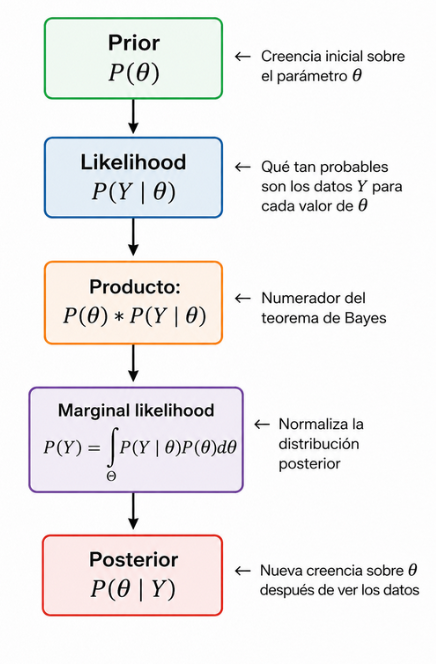

###  <font color="pink"> **El problema de la moneda**

Sea θ la probabilidad de obtener cara.

$θ∈[0,1]$ representa el sesgo de la moneda.

Observamos una serie de lanzamientos para inferir el valor de $θ$.

Aplicaremos el Teorema de Bayes:

$$p(θ∣Y)∝p(Y∣θ)p(θ)$$





### **Primer paso: definir el prior**

Necesitamos representar nuestra creencia inicial sobre $θ$.

Elegimos una distribución Beta:

$$p(θ)∝θ^{α−1}(1−θ)^{β−1}$$

¿Por qué Beta?

$θ∈[0,1]$.

Es muy flexible.

Permite obtener una solución analítica junto con la distribución Binomial.

### **Ejemplo concreto:**

 supongamos que la moneda es tirada por tres personas diferentes:**

 a) La primera persona dice que no tiene información sobre la moneda, por lo tanto _a priori_ todos los valores de $\theta$ son igualmente probables.

 b) La segunda persona desconfía de la moneda porque tiene la sospecha de que es una moneda que está cargada, por lo tanto considera que está sesgada aunque no sabe para cual de las dos opciones.
 c) La tercera persona asegura que lo más probable es que $\theta$ tome un valor alrededor de 0.5, pues se informó con experimentos previos similares.

 Modelizamos entonces cada caso:

/tmp/ipykernel_1355/276292782.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


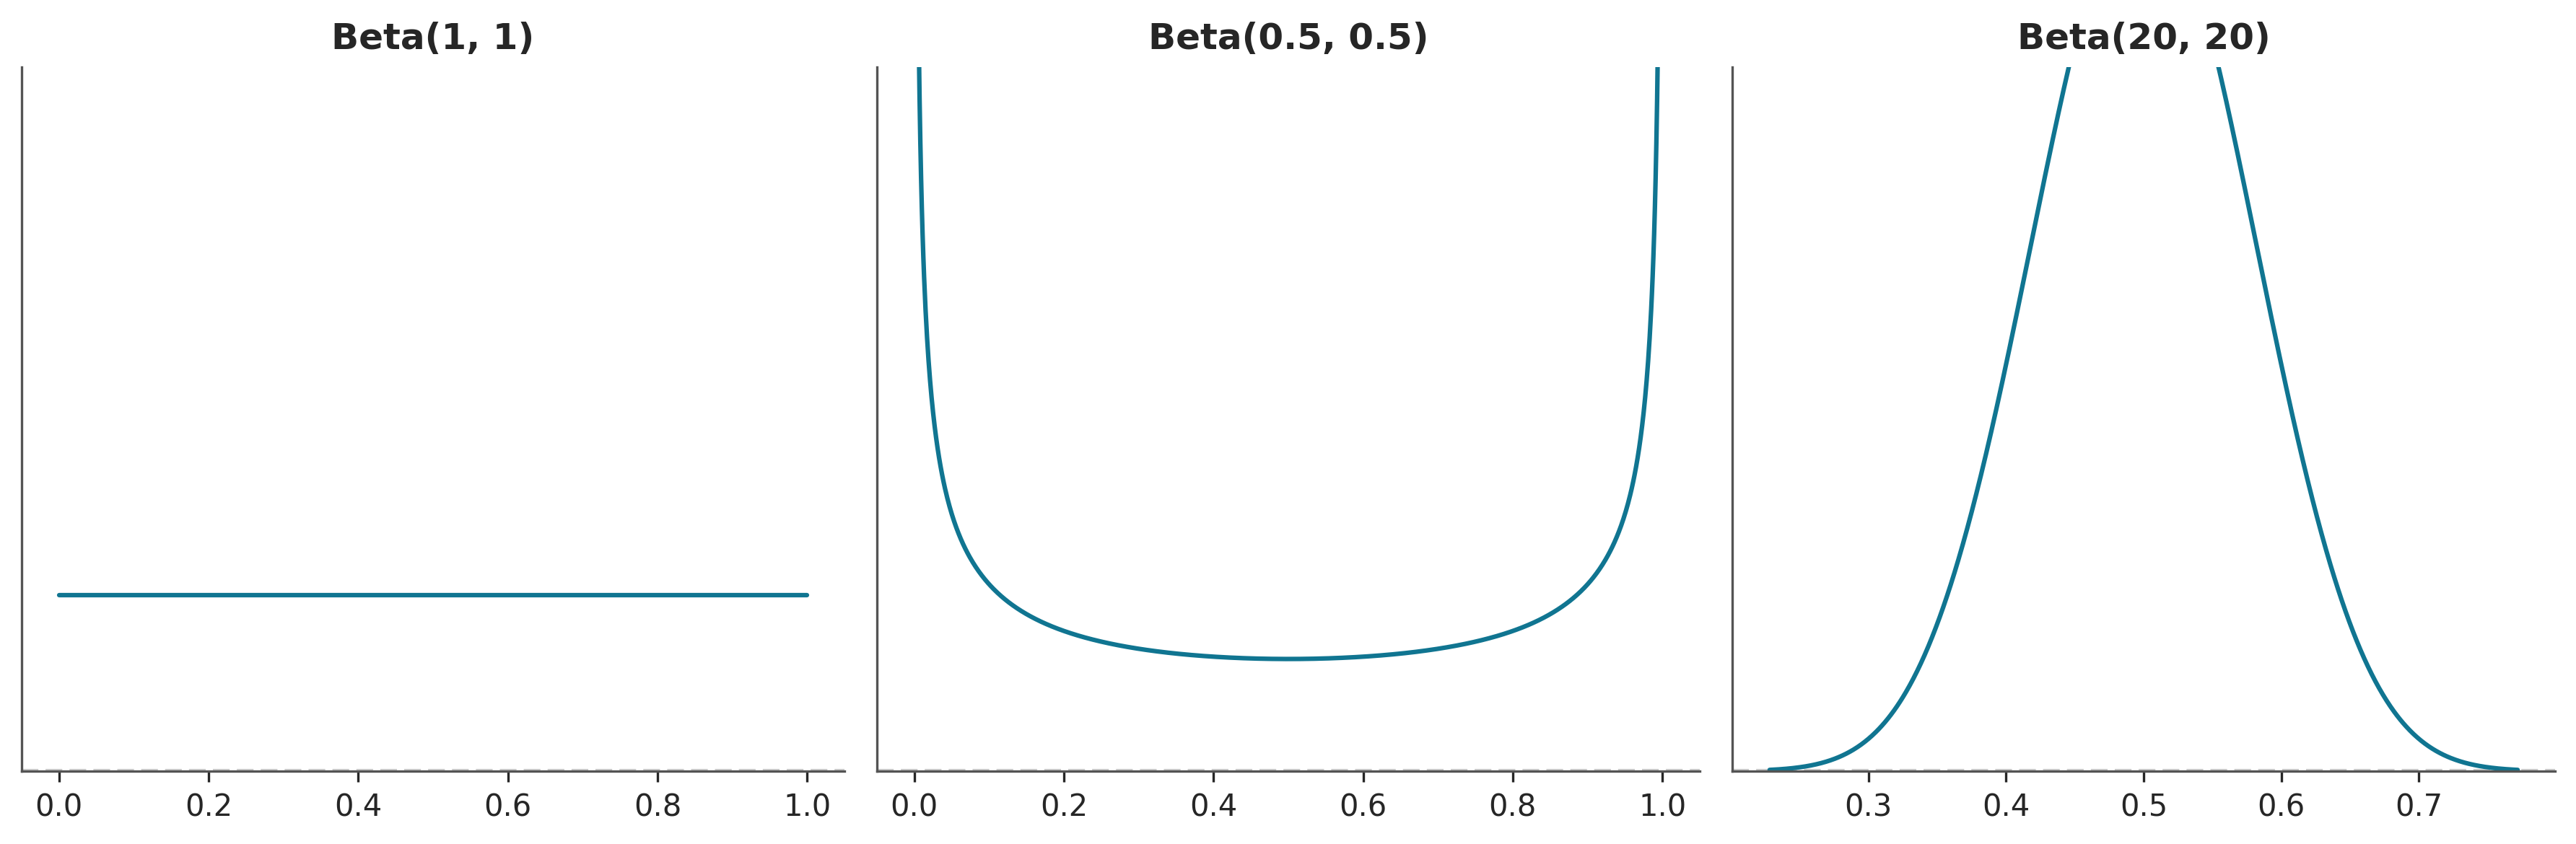

In [4]:
#1

_, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

params = [(1, 1), (0.5, 0.5), (20, 20)]

for (a, b), ax in zip(params, axes):
    ax = pz.Beta(a, b).plot_pdf(ax=ax, legend="title")
    ax.set_ylim(0, 4)
    ax.tick_params(labelsize=10)
    ax.set_title(f"Beta({a}, {b})", fontsize=12)

plt.tight_layout()

**¿Qué observamos?:**

Primera imagen: distribución uniforme → ignorancia total sobre el caso

Segunda imagen: La curva en U → sospecha de sesgo.

Tercera imagen: La campana ajustada en 0.5 → confianza en una moneda justa.

**Explorando la distribución Beta:**



In [3]:
#2

pz.Beta().plot_interactive(
    xy_lim=(None, None, None, 10),
    figsize=(3, 2)
)

interactive(children=(FloatSlider(value=2.0, description='alpha (0, inf)', max=12.0, min=2.220446049250313e-16…

Responder:

¿cómo cambian las distribuciones al modificar los parámetros α y β?

¿qué distribuciones representan mayor o menor incertidumbre?

¿cuándo la distribución favorece valores cercanos a 0, a 1 o al centro?

¿cómo se representa una creencia “neutral”?

¿cómo distribuciones más concentradas reflejan mayor confianza sobre ciertos valores del parámetro?



En particular, observen que si $α=β$, la distribución es simétrica, además de que valores grandes generan distribuciones más concentradas y valores pequeños producen distribuciones más dispersas o extremas...

###  <font color="pink"> Segundo paso: definir el _likelihood_


Suponemos que:

Cada lanzamiento es independiente.
La probabilidad de obtener cara es siempre $θ$.

Entonces,

$Y∼Bin(N,θ)$

y la verosimilitud viene dada por


$$p(y \mid \theta)=\binom{N}{y}\theta^{y}(1-\theta)^{N-y}$$


Como el coeficiente binomial no depende de θ,

$$p(y∣θ)∝θ^{y}(1−θ)^{N−y}$$

In [6]:
#3
pz.Binomial(1, 0.5).plot_interactive(pointinterval=False, xy_lim=(None, None, None, 1), figsize=(3,1))

interactive(children=(IntSlider(value=1, description='n (0, inf)', max=11, style=SliderStyle(description_width…

Observemos que si consideramos una Bin(1, 0.5) → es decir el caso equilibrado.



### <font color="pink"> Tercer paso: obtener el _a posteriori_


Tercer paso: obtener el posterior

Aplicando el Teorema de Bayes,

$$p(θ∣y)∝p(y∣θ)p(θ)$$

Si $p(θ)=Beta(α,β)$ y $Y∼Bin(N,θ)$,

entonces el posterior también es una Beta:

$$p(θ∣y)=Beta(α+y,β+N−y)$$

Los datos actualizan los parámetros del prior.


***Prior conjugado***

En este ejemplo, un prior Beta combinado con una likelihood Binomial produce nuevamente un posterior Beta.

Esta propiedad, llamada conjugación, simplifica el cálculo del posterior y facilita la interpretación del modelo.

#  **¿Cómo representamos los modelos Bayesianos?**

Resumen del modelo bayesiano:

\begin{align}\theta &\sim \operatorname{Beta}(\alpha,\beta)\\Y &\sim \operatorname{Bin}(n=1,p=\theta)\end{align}

La primera línea indica que el parámetro desconocido θ, es decir, la probabilidad de obtener cara, se modela mediante una distribución Beta con parámetros α y β.

En el enfoque bayesiano, esto representa nuestra incertidumbre inicial sobre el verdadero valor del parámetro antes de observar datos.

La segunda línea establece que los datos observados Y siguen una distribución binomial con probabilidad de éxito θ. En este contexto, cada lanzamiento puede tomar únicamente dos resultados posibles:

cara (éxito),

o ceca (fracaso).

Cuando n=1, la distribución binomial coincide con una distribución Bernoulli, es decir, modela un único experimento binario.

Esta notación resume completamente el modelo probabilístico:

el prior describe nuestras creencias iniciales;

mientras que el likelihood describe cómo se generan los datos a partir del parámetro desconocido.



**<font color="teal"> ¡Pueden hacer pruebas arrojando una moneda ustedes mismos!**

# **Actividad:**

# Analizar un ejemplo con observaciones conocidas:
¿Cómo podemos conseguir los datos para nuestra aplicación del modelo anterior?:

Trabajaremos con un ejemplo con datos sintéticos, obtienidos mediante un generador de números (pseudo)aleatorios.


### Cálculo del _a posteriori_

Trabajemos con la expresión del _a posteriori_ desde el punto de vista computacional:



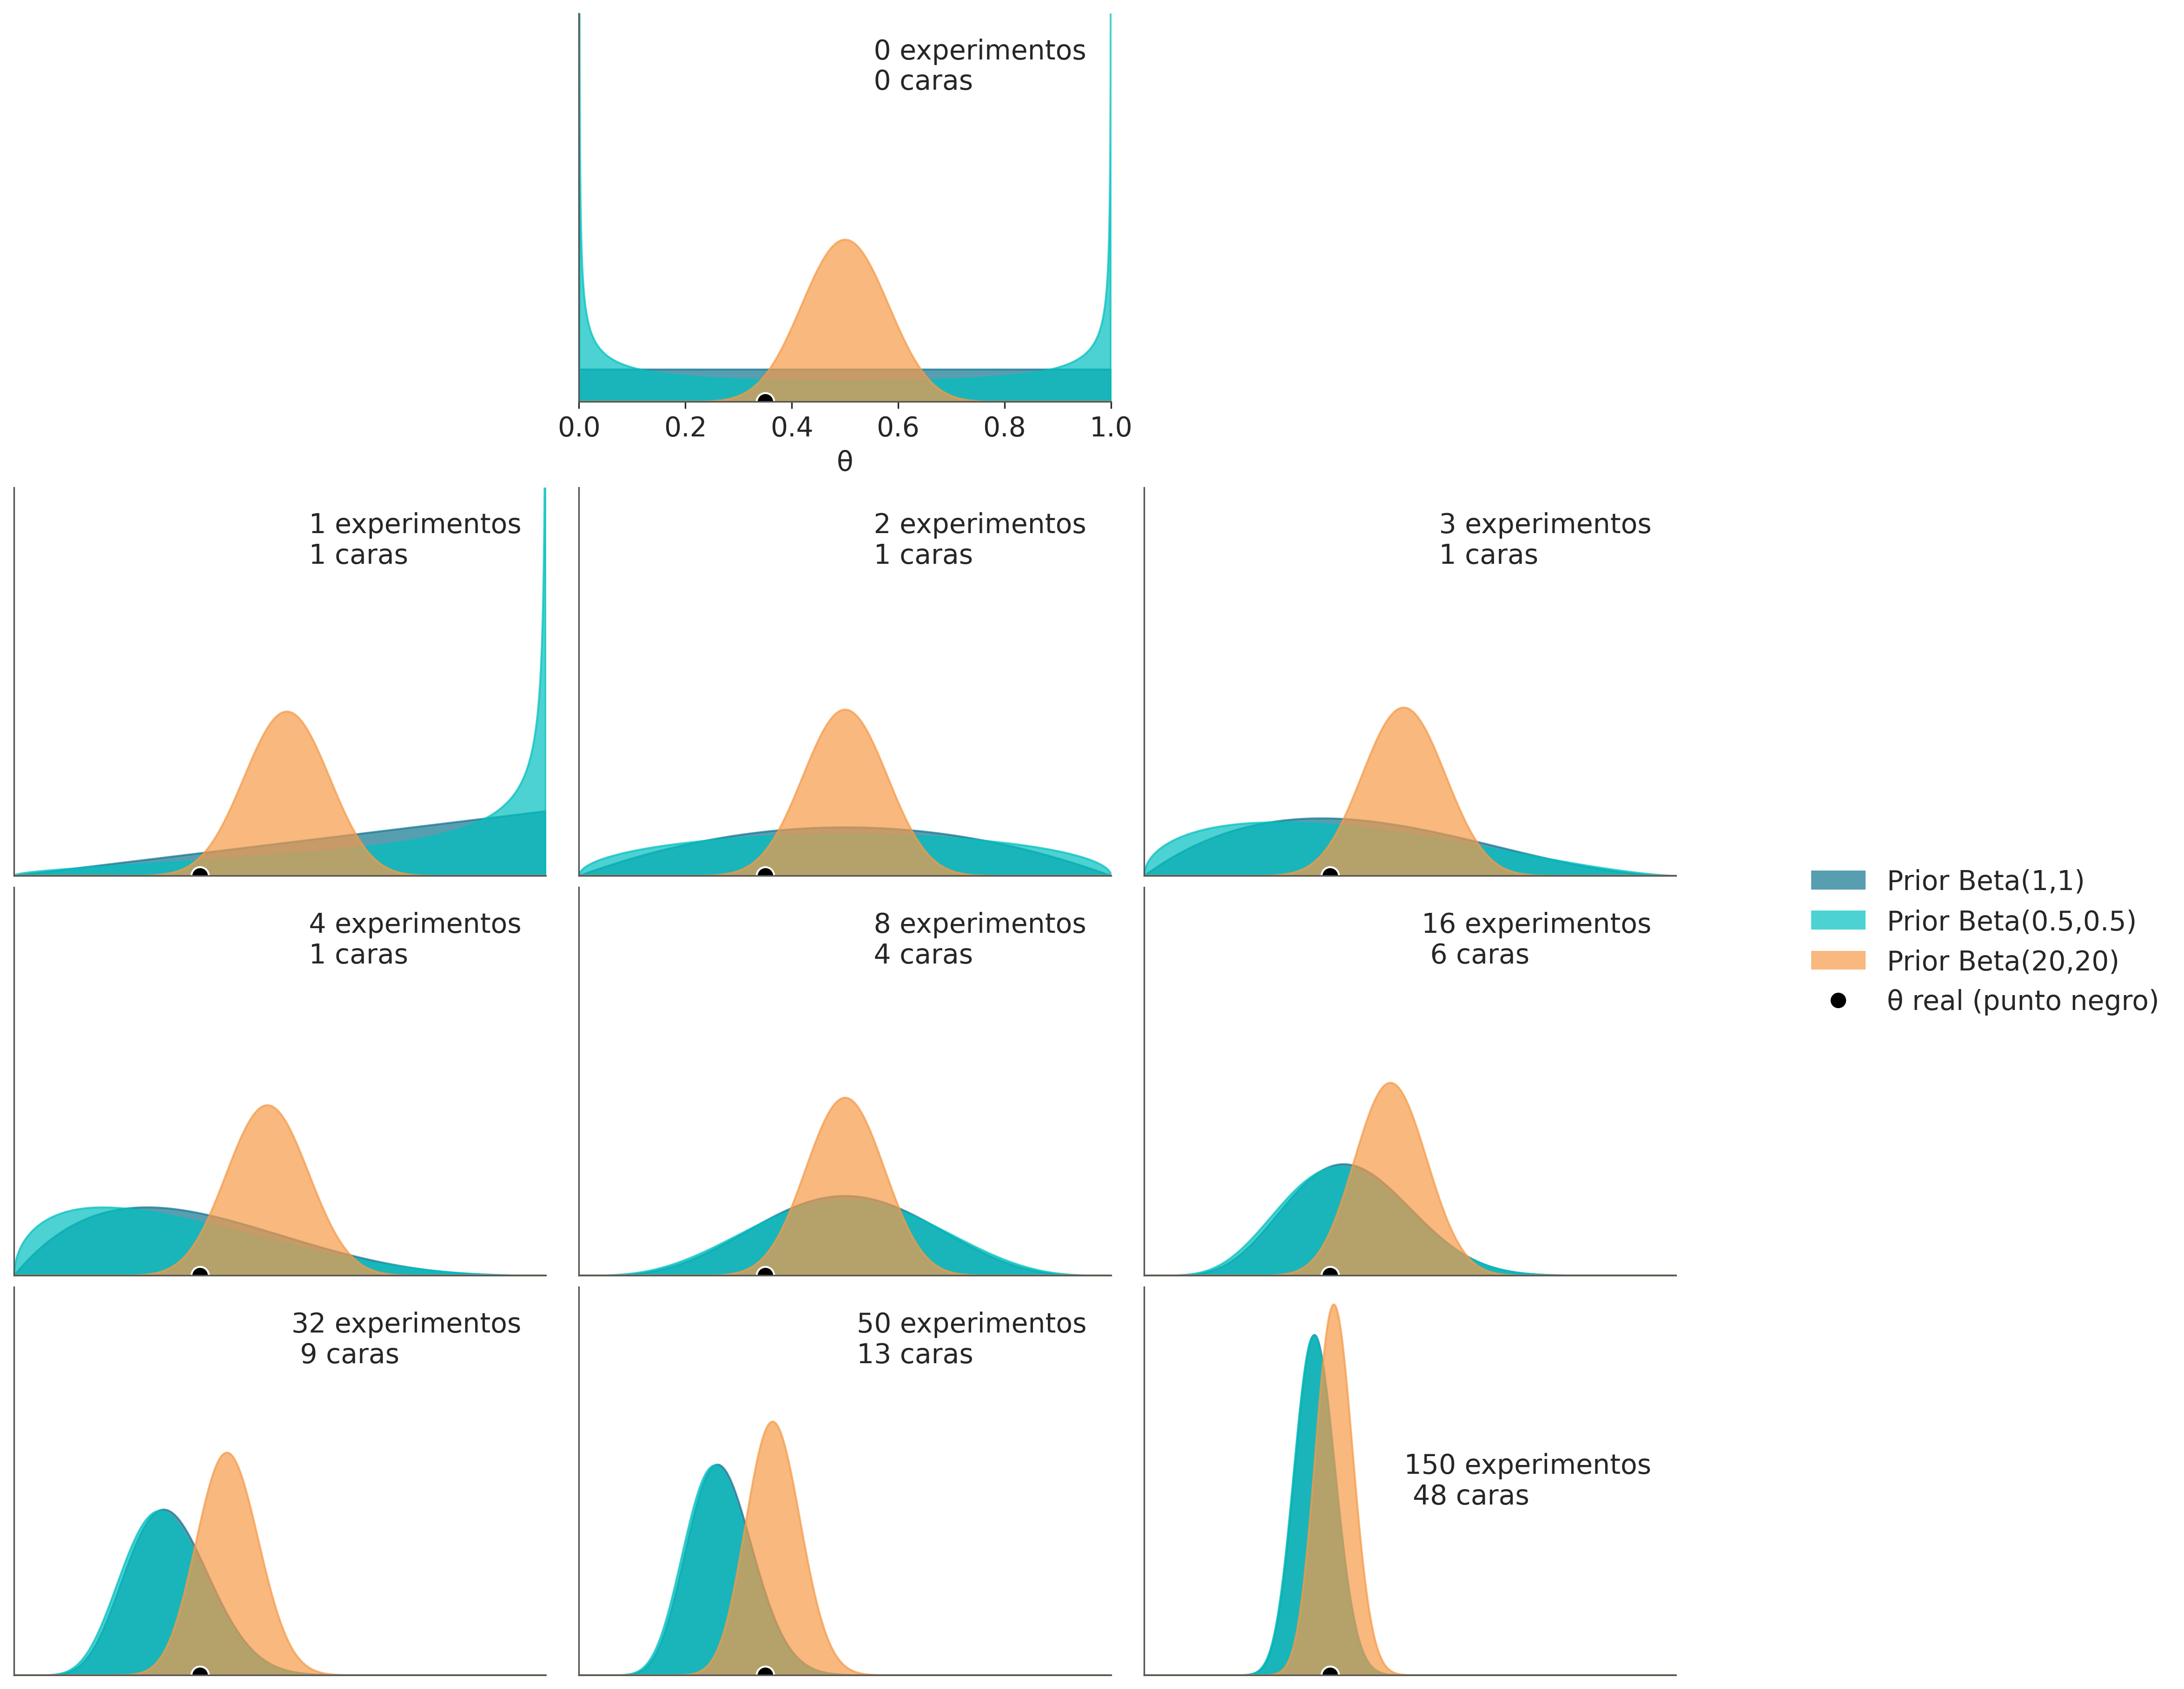

In [7]:
plt.figure(figsize=(12, 12))

n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
data = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
theta_real = 0.35

beta_params = [(1, 1), (0.5, 0.5), (20, 20)]
dist = pz.Beta
x = np.linspace(0, 1, 2000)

for idx, N in enumerate(n_trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
        plt.xlabel('θ')
    else:
        plt.subplot(4, 3, idx+3)
        plt.xticks([])
    y = data[idx]
    for i, (a_prior, b_prior) in enumerate(beta_params):
        posterior = dist(a_prior + y, b_prior + N - y).pdf(x)
        plt.fill_between(x, 0, posterior, alpha=0.7, color=f'C{i}')

    plt.plot(theta_real, 0, ms=9, marker='o', mec='w', mfc='k')
    plt.plot(0, 0, label=f'{N:4d} experimentos\n{y:4d} caras', alpha=0)
    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.yticks([])
    plt.legend()  # mantiene las etiquetas invisibles para cada subplot

# Leyenda
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='C0', alpha=0.7, label='Prior Beta(1,1)'),
    Patch(facecolor='C1', alpha=0.7, label='Prior Beta(0.5,0.5)'),
    Patch(facecolor='C2', alpha=0.7, label='Prior Beta(20,20)'),
    Line2D([0], [0], marker='o', color='w', label='θ real (punto negro)', markerfacecolor='k', markersize=9)
]

plt.gcf().legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 0.5))

plt.show()

Observaciones:

Al analizar el código es importante notar que gran parte de las líneas están dedicadas a la visualización de resultados y no al cálculo estadístico en sí mismo.

De hecho, el cálculo del a posteriori ocurre únicamente en una línea específica del programa. Allí se evalúa la distribución posterior utilizando la función pdf de la distribución Beta provista por la librería *PreliZ*.

El procedimiento es relativamente sencillo:

se generan 2000 valores igualmente espaciados entre 0 y 1 y luego se calcula la densidad posterior para cada uno de esos puntos.

Esto permite obtener una representación suave de la distribución posterior y visualizar cómo cambian nuestras creencias sobre el parámetro $θ$.

Además, el ciclo for presente en el código tiene como objetivo estudiar cómo evoluciona la distribución posterior a medida que aumenta la cantidad de datos observados (n_intentos).

De esta forma puede verse claramente una de las ideas centrales de la inferencia bayesiana:

1. con pocos datos, el prior tiene una influencia importante;
2. mientras que, al aumentar la evidencia observacional, el posterior comienza  a concentrarse alrededor de los valores más compatibles con los datos.

Finalmente, en los gráficos se marca con un círculo negro el valor verdadero de $θ$. En un problema real este valor sería desconocido, pero en este caso resulta útil porque los datos fueron generados artificialmente y conocemos exactamente el parámetro utilizado para simularlos. Esto permite comparar visualmente qué tan bien el modelo logra recuperar el valor real a partir de los datos observados.

## Analizando los resultados ¿ Qué nos muestran estos gráficos?



**Interpretación de los resultados:**

La primera figura muestra las distribuciones a priori, es decir, nuestras creencias sobre el valor de θ antes de observar datos.

Las figuras restantes muestran cómo estas distribuciones se actualizan al incorporar resultados de lanzamientos de moneda. En cada gráfico se indica:

la cantidad de experimentos realizados;
y la cantidad de caras observadas.

Además, el punto negro marca el valor verdadero de $θ=0.35$, conocido únicamente porque los datos fueron simulados.

Este ejemplo permite observar varias ideas importantes de la inferencia bayesiana:

El resultado de un análisis bayesiano no es un único número, sino una distribución completa de valores plausibles para el parámetro.

El ancho de la distribución refleja el nivel de incertidumbre:

distribuciones anchas indican mayor incertidumbre;

distribuciones más concentradas indican mayor confianza sobre ciertos valores.

El valor más probable corresponde al pico de la distribución posterior.

A medida que aumenta la cantidad de datos observados, la incertidumbre disminuye y las distribuciones se vuelven más concentradas.

Aunque distintos prioris produzcan resultados diferentes al comienzo, con suficientes datos las distribuciones posteriores tienden a parecerse.

Los prioris más informativos (más concentrados) necesitan una mayor cantidad de datos para ser modificados significativamente.

Con muy pocos datos, el prior puede influir fuertemente en las conclusiones obtenidas.

En cambio, cuando la cantidad de observaciones crece, los datos dominan progresivamente la inferencia.

Finalmente, puede observarse que el prior uniforme representa una postura relativamente “neutral”, ya que inicialmente asigna probabilidades similares a todos los valores posibles de $θ$.

**¿Cuántos datos hacen falta?**

No existe una respuesta universal. La rapidez con la que “desaparece” la influencia del prior depende tanto del problema como del tipo de prior utilizado.

En el ejemplo de la moneda vimos que:

algunos prioris producen resultados muy similares luego de pocas observaciones;
mientras que prioris más concentrados requieren una mayor cantidad de datos para ser modificados significativamente.

Esto ocurre porque un prior muy concentrado representa una creencia previa fuerte. Por ejemplo, un prior como:

$Beta(20,20)$

asigna gran parte de la probabilidad a valores cercanos a 0.5, indicando una fuerte creencia inicial en que la moneda es aproximadamente equilibrada.

En cambio, un prior como:

$Beta(2,2)$

también favorece valores cercanos a 0.5, pero de manera mucho más flexible y menos restrictiva.

**¿Los prioris “contaminan” el análisis?**

La elección del prior suele generar dudas en quienes se acercan por primera vez a la Estadística Bayesiana. Una preocupación frecuente es pensar que el prior podría “forzar” los resultados o impedir que los datos “hablen por sí mismos”.

Sin embargo, los datos nunca se interpretan de manera aislada. Todo análisis estadístico necesita supuestos y modelos para poder extraer conclusiones.

En el enfoque bayesiano, los prioris forman parte explícita de esos supuestos.

Lejos de ser un problema, esto aporta transparencia:

* las hipótesis quedan visibles;
* pueden discutirse;
* y también pueden modificarse o compararse.

**Prioris no informativos e informativos**

En términos generales, los prioris suelen clasificarse según la cantidad de información previa que incorporan.

***Prioris no informativos***

También llamados *planos, vagos, o difusos*.

Buscan introducir la menor cantidad posible de información previa, permitiendo que los datos dominen rápidamente la inferencia.

En muchos casos, utilizar prioris poco informativos conduce a resultados similares a los obtenidos mediante métodos frecuentistas.

Por ejemplo, en el caso binomial, la estimación frecuentista clásica para $θ$ es:

$$\hat{θ}=\frac{y}{N}$$
	​


A diferencia del enfoque bayesiano, esta estimación corresponde únicamente a un valor puntual y no a una distribución completa de incertidumbre.

**Prioris ligeramente informativos**

En la práctica, muchas veces sí disponemos de cierta información previa razonable:

sabemos que un parámetro debe ser positivo;

que una probabilidad debe estar entre 0 y 1;

o que ciertos valores extremos son poco plausibles.

En estos casos resulta útil utilizar prioris ligeramente informativos, que ayudan a mantener las inferencias dentro de rangos razonables sin imponer restricciones demasiado fuertes.

Este tipo de prioris suele actuar como un mecanismo de regularización.

**Prioris informativos**

Cuando existe información previa confiable, también es posible utilizar prioris fuertemente informativos.

Esto puede ser especialmente útil cuando:

los datos disponibles son escasos;

o el problema contiene mucho ruido e incertidumbre.

En disciplinas como bioinformática, medicina o física experimental, es común aprovechar información acumulada durante años de investigaciones previas. Ignorar ese conocimiento muchas veces sería poco razonable.

**No existen modelos “sin prior”**

Desde una perspectiva bayesiana, todo modelo incorpora supuestos previos, incluso cuando estos no aparecen escritos explícitamente.

De hecho, muchos procedimientos frecuentistas pueden interpretarse como casos particulares de modelos bayesianos con prioris planos o débiles.

Por este motivo, especificar los prioris de manera explícita suele ser más transparente que asumirlos implícitamente.

Además, hacerlo permite:

controlar mejor el modelo;

estudiar cómo afectan los supuestos a las conclusiones;

y cuantificar adecuadamente la incertidumbre.

**Sensibilidad y comparación de modelos**

El modelado estadístico es un proceso iterativo. Nada obliga a utilizar un único prior.

En muchos problemas resulta útil comparar distintos prioris razonables y analizar cómo cambian los resultados. Esto se conoce como análisis de sensibilidad.

Si las conclusiones permanecen estables frente a distintos prioris, entonces podemos tener mayor confianza en la robustez del análisis.

Más adelante veremos herramientas que permiten comparar modelos y evaluar formalmente diferentes elecciones de prioris y likelihoods.

Con los ejemplos anteriores podemos concluir que la elección del a priori influye sobre los resultados obtenidos, pues si el prior no tuviera ningún efecto, entonces no tendría sentido incluirlo en el análisis bayesiano.

Además, a medida que aumenta la cantidad de datos disponibles, la influencia del prior disminuye progresivamente. Esto significa que cuando la evidencia observacional es abundante, el posterior queda dominado principalmente por los datos.
Incluso se puede observar que bajo ciertas condiciones, con una cantidad suficientemente grande de observaciones, los distintos prioris tienden a conducir a conclusiones similares.

## **Cuantificando el peso del _a priori_**

Si queremos expresar la distribución Beta en función de la media y el desvío, podemos realizar las siguientes conversioens:

\begin{align}
\alpha &= \mu \kappa \\
\beta &= (1 - \mu) \kappa
\end{align}

donde $\mu$ es la media y $\kappa$ es un parámetro llamado concentración. Por ejemplo si $\mu=0.5$ y $\kappa=40$, tenemos que:

\begin{align}
\alpha = 0.5 \times 40 &= 20 \\
\beta = (1-0.5) \times 40 &= 20
\end{align}

donde $\kappa$ sería la cantidad de experimentos "si/no" que realizamos dándonos como resultado la media $\mu$.

* Es decir el _a priori_ no sesgado (naranja) equivale a haber arrojado una moneda 40 veces y haber obtenido como media 0.5. Es decir que si usamos ese _a priori_ recién al observar 40 experimentos si/no, los datos tendrán el mismo peso relativo que el _a priori_, por debajo de este número el _a priori_ contribuye más que los datos al resultado final y por encima menos.

Observemos:

* El _a priori_ azul (uniforme) equivale a haber observado a la moneda caer una vez cara y otra vez ceca ($\kappa = 2$).

* Cuando $\kappa < 2$, la cosa se pone un poco extraña, por ejemplo el _a priori_ sesgado (turquesa) equivale a haber observado una sola moneda ($\kappa = 1$) pero en una especie de, a falta de mejor analogía, ¡¿_superposición cuántica de estados_?!

### Resumiendo el  _a posteriori_

El resultado de un análisis Bayesiano es siempre una distribución de probabilidad.

A la hora de comunicar los resultados de un análisis Bayesiano, lo más informativo es reportar la distribución completa, aunque esto no siempre es posible o deseable, por ejemplo el _a posteriori_ de una distribución multidimensional es imposible de visualizar de forma directa. Por lo tanto, es común recurrir a distintas medidas que resumen el _a posteriori_, por ejemplo la media, mediana, la desviación estándar, etc. También es común, e informativo, reportar un intervalo de credibilidad. Existen varios criterios para definir intervalos de credibilidad, el que usaremos en este curso (y que también es ampliamente usado en la literatura) es lo que se conoce como intervalo de más alta densidad y nos referiremos a él por su sigla en ingles, HDI (_Highest Posterior Density interval_). Un HDI es el intervalo, más corto, que contiene una porción fija de la densidad de probabilidad, generalmente el 95% (aunque otros valores como 90% o 50% son comunes). Cualquier punto dentro de este intervalo tiene mayor densidad que cualquier punto fuera del intervalo. Para una distribución unimodal, el HDI 95 es simplemente el intervalo entre los percentiles 2,5 y 97,5.


Profundizaremos en el siguiente capítulo cómo dar tratamiento computacional a problemas bayesianos simple con funcionalidades de Python, en particular, *ArviZ* es un paquete de Python para análisis exploratorio de modelos Bayesianos que nos permite obtener funciones para analizar y resumir el _a posteriori_.

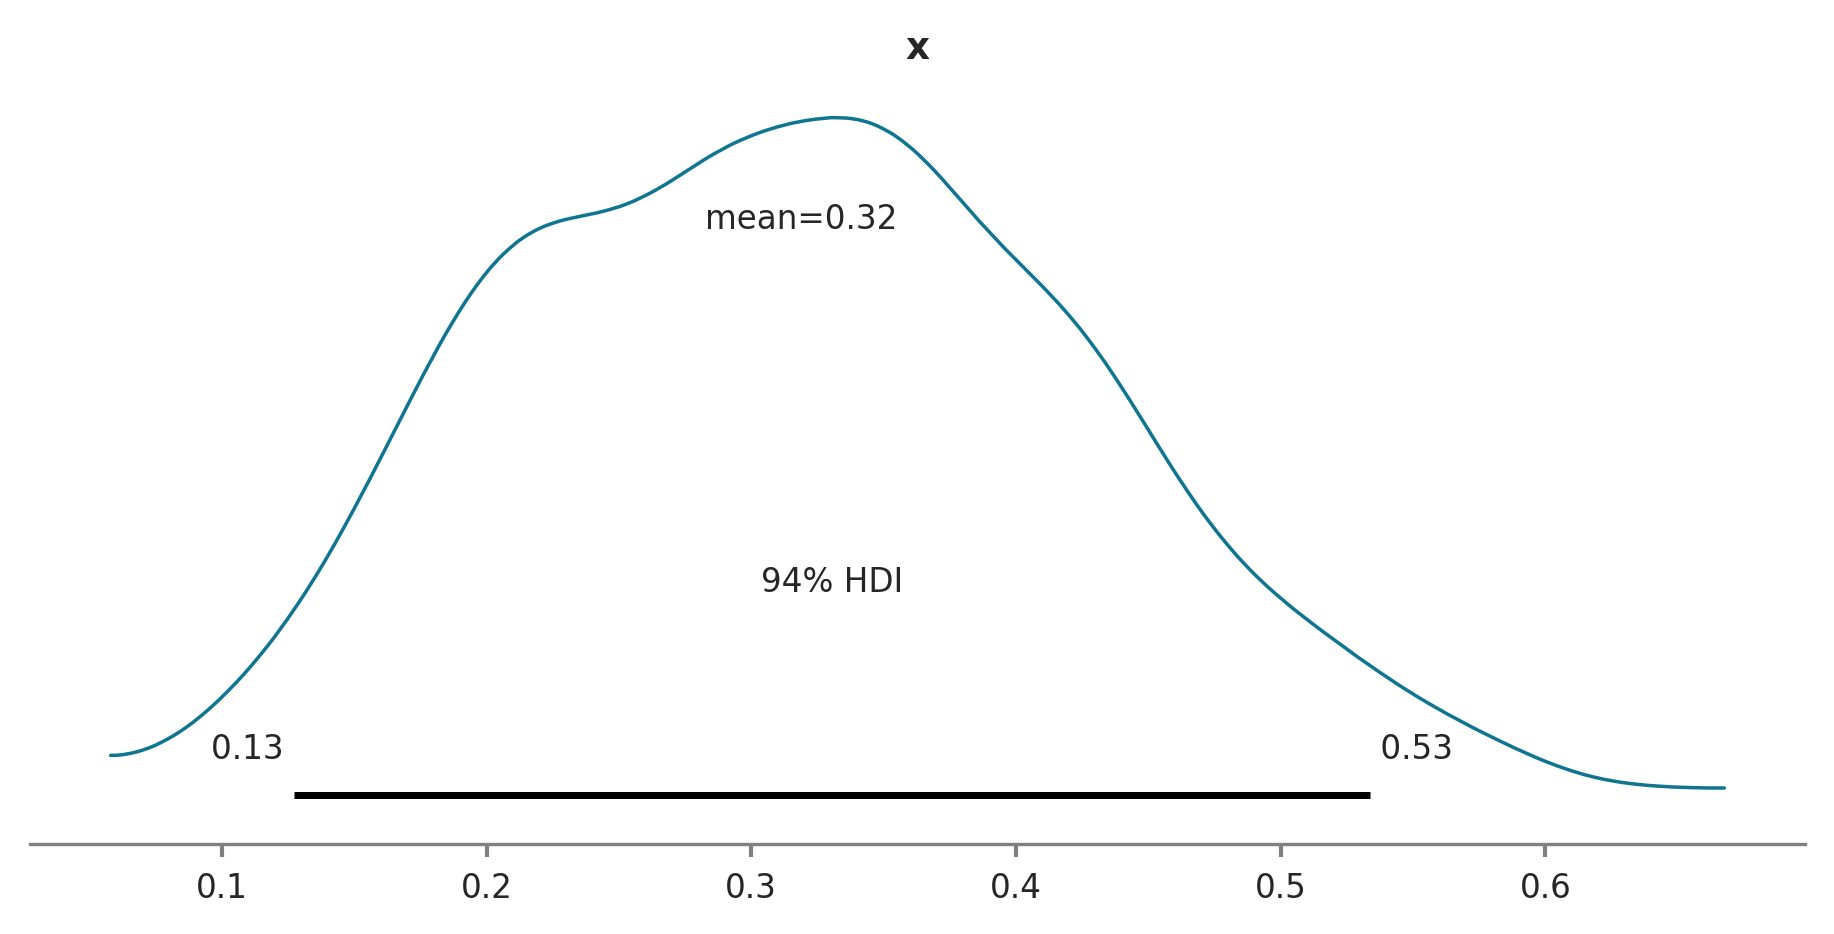

In [8]:
mock_posterior = pz.Beta(5, 11).rvs(size=1000)
az.plot_posterior(mock_posterior, figsize=(6, 3));